# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
# sns.set_theme()
sns.set_theme(style="white")
# sns.set_style('whitegrid')

In [3]:
# Load selected group_id
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

In [ ]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

mean_num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")
    mean_num_neuron.append(np.mean(num_cross_pop))

probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id'].isin([0,1,2]))]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons. ")
    num_neuron.append(np.mean(num_cross_pop))# Load data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
#                    stimulus_condition_id=[246, 247, 248, 249, 250, 251, 252, 253, 255, 256, 257, 258, 259, 260, 261, 
#                                           262, 263, 264, 265, 266, 267, 268, 269, 271, 272, 273, 274, 275, 276, 277,
#                                           278, 279, 280, 281, 282, 283, 284, 285, 286, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

probeA has 12.225 neurons in cross-pop in average. 
probeB has 14.95 neurons in cross-pop in average. 
probeC has 16.9 neurons in cross-pop in average. 
probeD has 10.625 neurons in cross-pop in average. 
probeE has 7.375 neurons in cross-pop in average. 
probeF has 8.225 neurons in cross-pop in average. 
probeA has 64.0 neurons. 
probeB has 60.0 neurons. 
probeC has 85.0 neurons. 
probeD has 53.0 neurons. 
probeE has 53.0 neurons. 
probeF has 37.0 neurons. 


/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


In [ ]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

mean_num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id']==0)]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons in cross-pop in average. ")
    mean_num_neuron.append(np.mean(num_cross_pop))

In [ ]:
probe_list = ['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF']

num_neuron = []
for iprobe, probe in enumerate(probe_list):
    num_cross_pop = []
    for icondition in range(len(membership)):
        aaa = membership[icondition]
        num_cross_pop.append( len(aaa[np.logical_and( aaa['probe']==probe , aaa['group_id'].isin([0,1,2]))]) )
    print(f"{probe} has {np.mean(num_cross_pop)} neurons. ")
    num_neuron.append(np.mean(num_cross_pop))

# Mean firing rate

In [ ]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.7,3.5),dpi=300)

transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}
num_basis_baseline1 = [25,25,25,25-10,25,25-10]
num_basis_baseline2 = [30,30,30,30-10,30,30-10]
probe_list = V1.selected_probes

for ii, target_probe in enumerate(probe_list):
    i = transfer_ij[ii]
    plt.subplot(2, 3, ii+1)
    
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline1[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, penalty=1, smoothing=1e5)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'r'
    label = 'Running'
    plt.plot(x, np.exp(y.squeeze())*1e3/mean_num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/mean_num_neuron[i], np.exp(y+2*ci)*1e3/mean_num_neuron[i], 
                     color=color, alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline2[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, penalty=1, smoothing=1e5)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'b'
    label = 'Stationary'
    plt.plot(x, np.exp(y.squeeze())*1e3/mean_num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/mean_num_neuron[i], np.exp(y+2*ci)*1e3/mean_num_neuron[i],
                     color=color, alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    plt.xlabel('Time (ms)')
    plt.ylabel('Firing rate per neuron \n (spike/sec)')

    if ii==0:
        plt.legend()
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])
    
plt.tight_layout()
plt.savefig('Figures/SupFig/use all mean firing rate.pdf', format='pdf', dpi=300)


/tmp/ipykernel_20201/3883280898.py:11: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2, 3, ii+1)
/tmp/ipykernel_20201/3883280898.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_20201/3883280898.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_20201/3883280898.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_20201/3883280898.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
/tmp/ipykernel_20201/3883280898.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


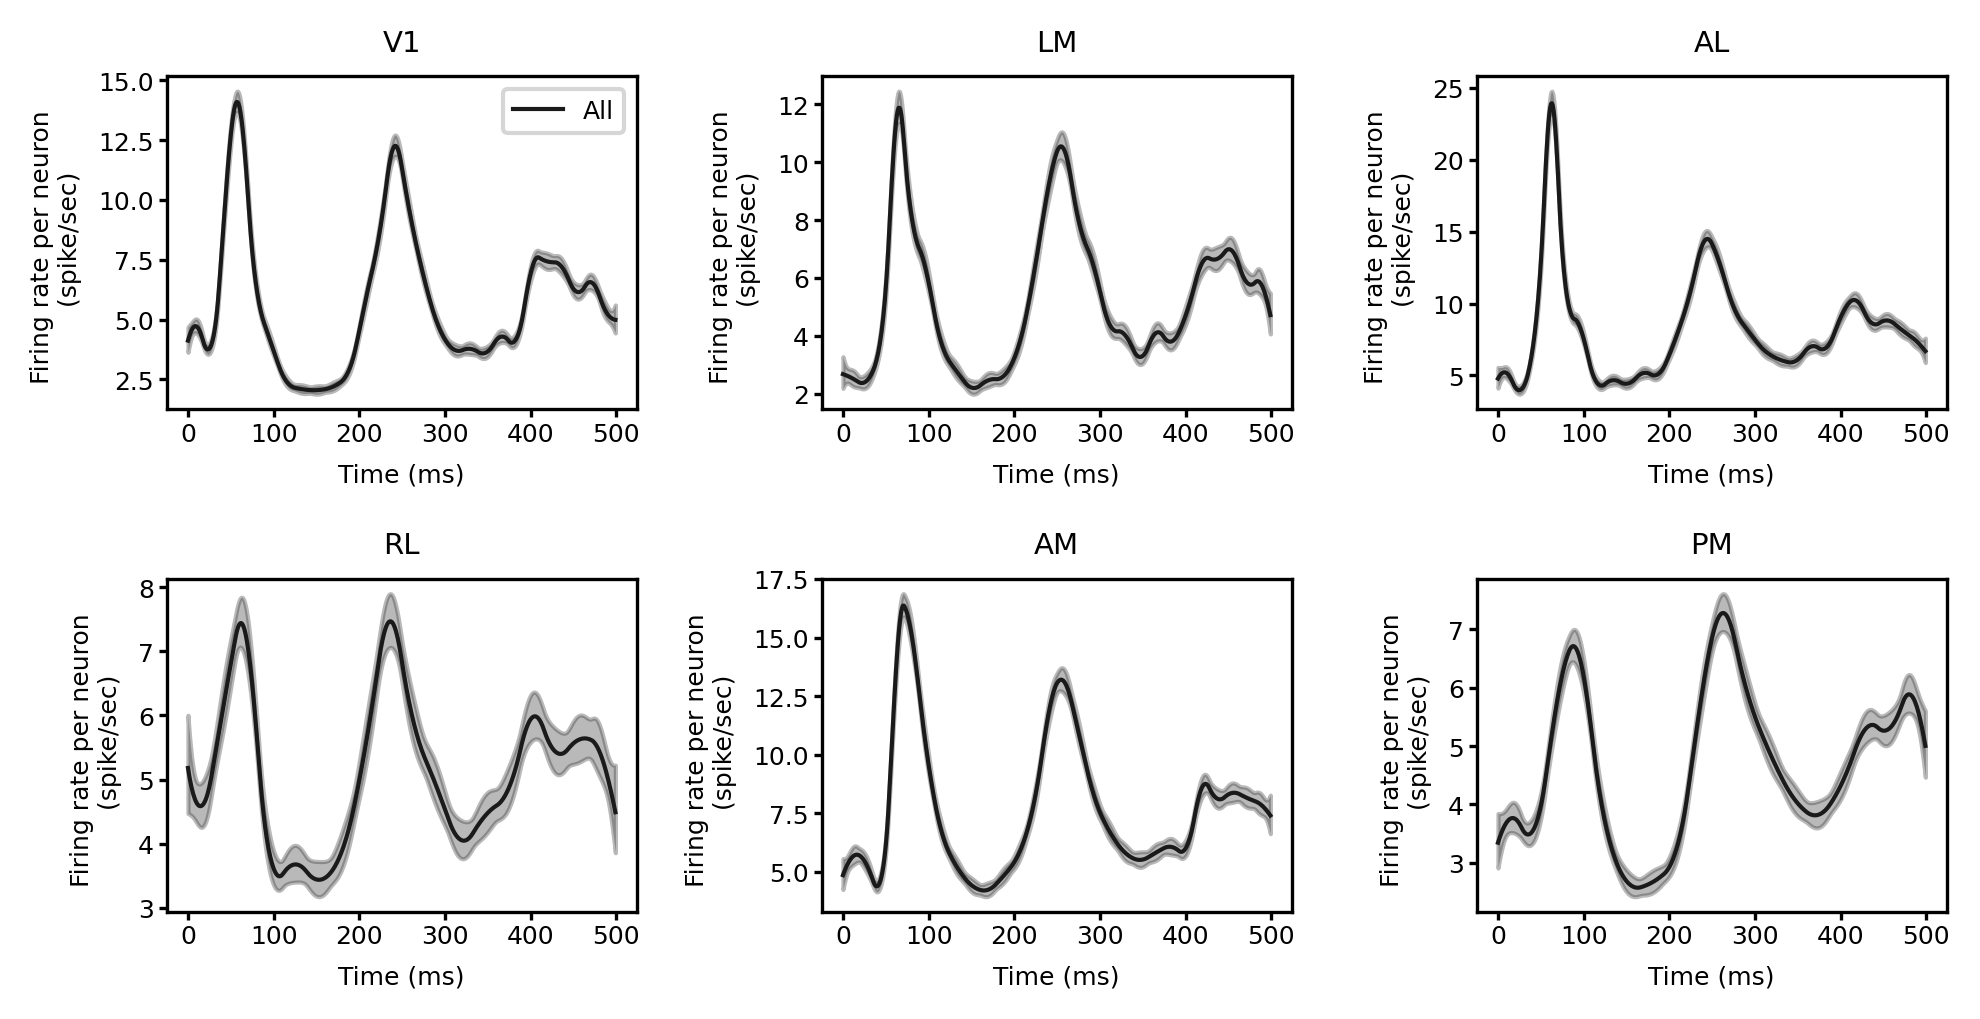

In [10]:
utils.use_pdf_plot()
plt.subplots(figsize=(6.7,3.5),dpi=300)

transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}
num_basis_baseline1 = [25,25,25,25-10,25,25-10]
num_basis_baseline2 = [30,30,30,30-10,30,30-10]
probe_list = V1.selected_probes

for ii, target_probe in enumerate(probe_list):
    i = transfer_ij[ii]
    plt.subplot(2, 3, ii+1)

    select_trials = np.array([True]*V1.ntrial)
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline2[ii], add_constant_basis=False)
    model.fit(probe_list[i], verbose=False, use_all=True, penalty=1)
    x = model.dataset.time_line*1e3
    y, ci = model.get_filter_output(ci=True, intermediate=False)[0]
    color = 'k'
    label = 'All'
    plt.plot(x, np.exp(y.squeeze())*1e3/num_neuron[i],label=label, color=color)
    plt.fill_between(x, np.exp(y-2*ci)*1e3/num_neuron[i], np.exp(y+2*ci)*1e3/num_neuron[i],
                     color='k', alpha=.3)
#     plt.plot(x,1e3*utils.kernel_smoothing(model.output.mean(axis=1)[:, np.newaxis], std=15)/num_neuron[i],
#              label=label, color=color, linewidth=3)
    plt.xlabel('Time (ms)')
    plt.ylabel('Firing rate per neuron \n (spike/sec)')

    if ii==0:
        plt.legend()
    plt.title(utils.PROBE_CORRESPONDING[probe_list[i]])
    plt.tight_layout()

plt.show()
# plt.savefig('Figures/Mean_FR_ALL_BOTH.svg', format='svg', dpi=300)

# Fit six areas with 14 conditions

## Fit

In [12]:
# The following hyperparameters turned out to be the best
num_f_refractory = 4
max_iter = 10
tau = 15
coupling_filter_params = {'peaks_max':20.2, 'num':3, 'nonlinear':0.5}
num_basis_baseline = 20
penalty = 5e-1

################ No need to change below
probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_output = {}
stationary_output = {}

ROI_filter = {}
statistics_filter = {}
record_filter = {}
ROI_output = {}
statistics_output = {}
record_output = {}

running_model_list = []
stationary_model_list = []

for i, target_probe in tqdm(enumerate(probe_list)):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], apply_no_penalty=True, use_all=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, use_all=True, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, use_all=True, verbose=False, max_iter=max_iter, penalty=penalty)
    running_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        running_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(ci=True, intermediate=False)
    for j in range(len(model.basis_list)):
        running_output[i,j-1] = output_list[j]
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, apply_no_penalty=True)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], use_all=True, apply_no_penalty=True, **coupling_filter_params)
    model.add_effect('refractory_additive', target_probe, use_all=True, tau=tau, num=num_f_refractory, apply_no_penalty=True)
#     model.add_effect('refractory', target_probe, tau=tau, order=1.5, apply_no_penalty=True)
    model.add_effect('trial_coef')
    model.fit_time_warping_baseline(target_probe, use_all=True, verbose=False, max_iter=max_iter, penalty=penalty)
    stationary_model_list.append(model)
    
    filter_list = model.get_filter(ci=True)
    for j in range(len(model.basis_list)):
        stationary_filter[i,j-1] = filter_list[j]
    output_list = model.get_filter_output(ci=True, intermediate=False)
    for j in range(len(model.basis_list)):
        stationary_output[i,j-1] = output_list[j]


6it [04:11, 41.93s/it]


In [13]:
method = 'default'

for i, target_probe in (enumerate(probe_list)):
    # for effect filter
    filter_index = i,-1
    function1 = np.exp( running_filter[filter_index][0] )
    function2 = np.exp( stationary_filter[filter_index][0] )
    std1 = function1*np.exp(running_filter[filter_index][1]**2/2)*np.sqrt(np.exp(running_filter[filter_index][1]**2)-1)
    std2 = function1*np.exp(stationary_filter[filter_index][1]**2/2)*np.sqrt(np.exp(stationary_filter[filter_index][1]**2)-1)
    # statistics_filter[filter_index], ROI_filter[filter_index] = GLM.get_excursion_statistic_single_trial([function1, function2, std1, std2],
    #                                                                                                      method=method)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_filter[filter_index][0]
        function2 = stationary_filter[filter_index][0]
        std1 = running_filter[filter_index][1]
        std2 = stationary_filter[filter_index][1]
        statistics_filter[filter_index], ROI_filter[filter_index] = GLM.get_excursion_statistic_single_trial([function1, function2, std1, std2], 
                                                                                                            method=method)

    # for effect output
    filter_index = i,-1
    function1 = np.exp( running_output[filter_index][0] )
    function2 = np.exp( stationary_output[filter_index][0] )
    std1 = function1*np.exp(running_output[filter_index][1]**2/2)*np.sqrt(np.exp(running_output[filter_index][1]**2)-1)
    std2 = function1*np.exp(stationary_output[filter_index][1]**2/2)*np.sqrt(np.exp(stationary_output[filter_index][1]**2)-1)
    # statistics_output[filter_index], ROI_output[filter_index] = GLM.get_excursion_statistic_single_trial([function1, function2, std1, std2], 
    #                                                                                                     method=method)
    for j, input_probe in enumerate(probe_list):
        filter_index = i,j
        function1 = running_output[filter_index][0]
        function2 = stationary_output[filter_index][0]
        std1 = running_output[filter_index][1]
        std2 = stationary_output[filter_index][1]
        statistics_output[filter_index], ROI_output[filter_index] = GLM.get_excursion_statistic_single_trial([function1, function2, std1, std2], 
                                                                                                            method=method)

## Plot

Need to change in GLM plot_filter_with_excursion
change 15 to 16
```
{
if j==0:
    plt.yticks(color='k')
    plt.text(-16, 0.95*filter_amp, f'{filter_amp}', fontsize=SMALL_SIZE)
    plt.text(-2.1*filter_length, 0, f'To {name_list[i]}', fontsize=MEDIUM_SIZE)
if (j==1 and i==0):
    plt.yticks(color='k')
    plt.text(-16, 0.95*filter_amp, f'{filter_amp}', fontsize=SMALL_SIZE)
}
```

```
{
change 0.28 to 0.34

if i==0 and j==2:
    plt.subplot(6, 7, i*7+j+1+1, frameon=True)
    plt.text(-4.5*filter_length, 0, f'To V1', fontsize=MEDIUM_SIZE)
if i==1 and j==0:
    plt.subplot(6, 7, i*7+j+1+1, frameon=True)
    plt.text(0.2*filter_length, 3.8*filter_amp, f'From V1', fontsize=MEDIUM_SIZE)
if i==0 and j==-1:
    plt.subplot(6, 7, i*7+j+1+1, frameon=True)
    plt.text(-0.6*filter_length, 0.34, f'Inhomo baseline', fontsize=MEDIUM_SIZE)
    
}
```

In [18]:
GLM.plot_function_with_excursion(V1, stationary_filter, running_filter, inference=False, plot_baseline=True, 
                              plot_self=False, dpi=300, function_amp=0.08)
plt.savefig('Figures/SupFig/use all fitted filters.pdf', format='pdf', dpi=300)

# Below are copied from subgroup without running

Text(0.5, 1.0, 'Fitted with $f_{rf}(\\Lambda)$ model; LM; Resting; trial 85')

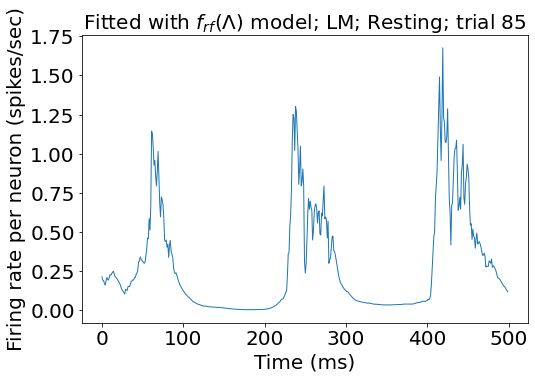

In [8]:
fontsize = 20
plt.subplots(figsize=(8,5.3))

# plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85])/10.625*1e3, linewidth=1)
plt.plot(np.exp(stationary_model_list[3].log_lmbd[:, 85]), linewidth=1)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.xlabel("Time (ms)", fontsize=fontsize)
plt.ylabel("Firing rate per neuron (spikes/sec)", fontsize=fontsize)
plt.title("Fitted with $f_{rf}(\Lambda)$ model; LM; Resting; trial 85", fontdict = {'fontsize' : 20})

Text(0.5, 1.0, '$\\beta_{V1, m}$')

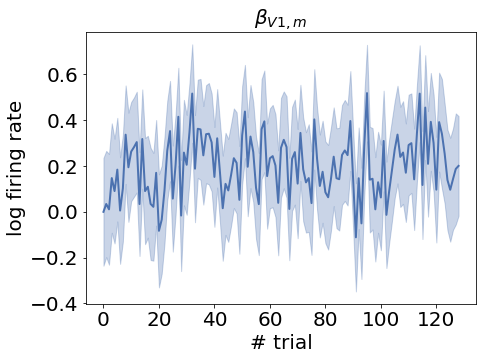

In [9]:
fontsize = 20
plt.subplots(figsize=(5*1.4,5))

utils.plot_ci(stationary_model_list[2].get_filter(ci=True)[8], center=True, linewidth=2)

plt.xlabel('# trial', fontsize=fontsize)
plt.ylabel('log firing rate', fontsize=fontsize)
plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)
plt.title(r'$\beta_{V1, m}$', fontdict = {'fontsize' : 20})

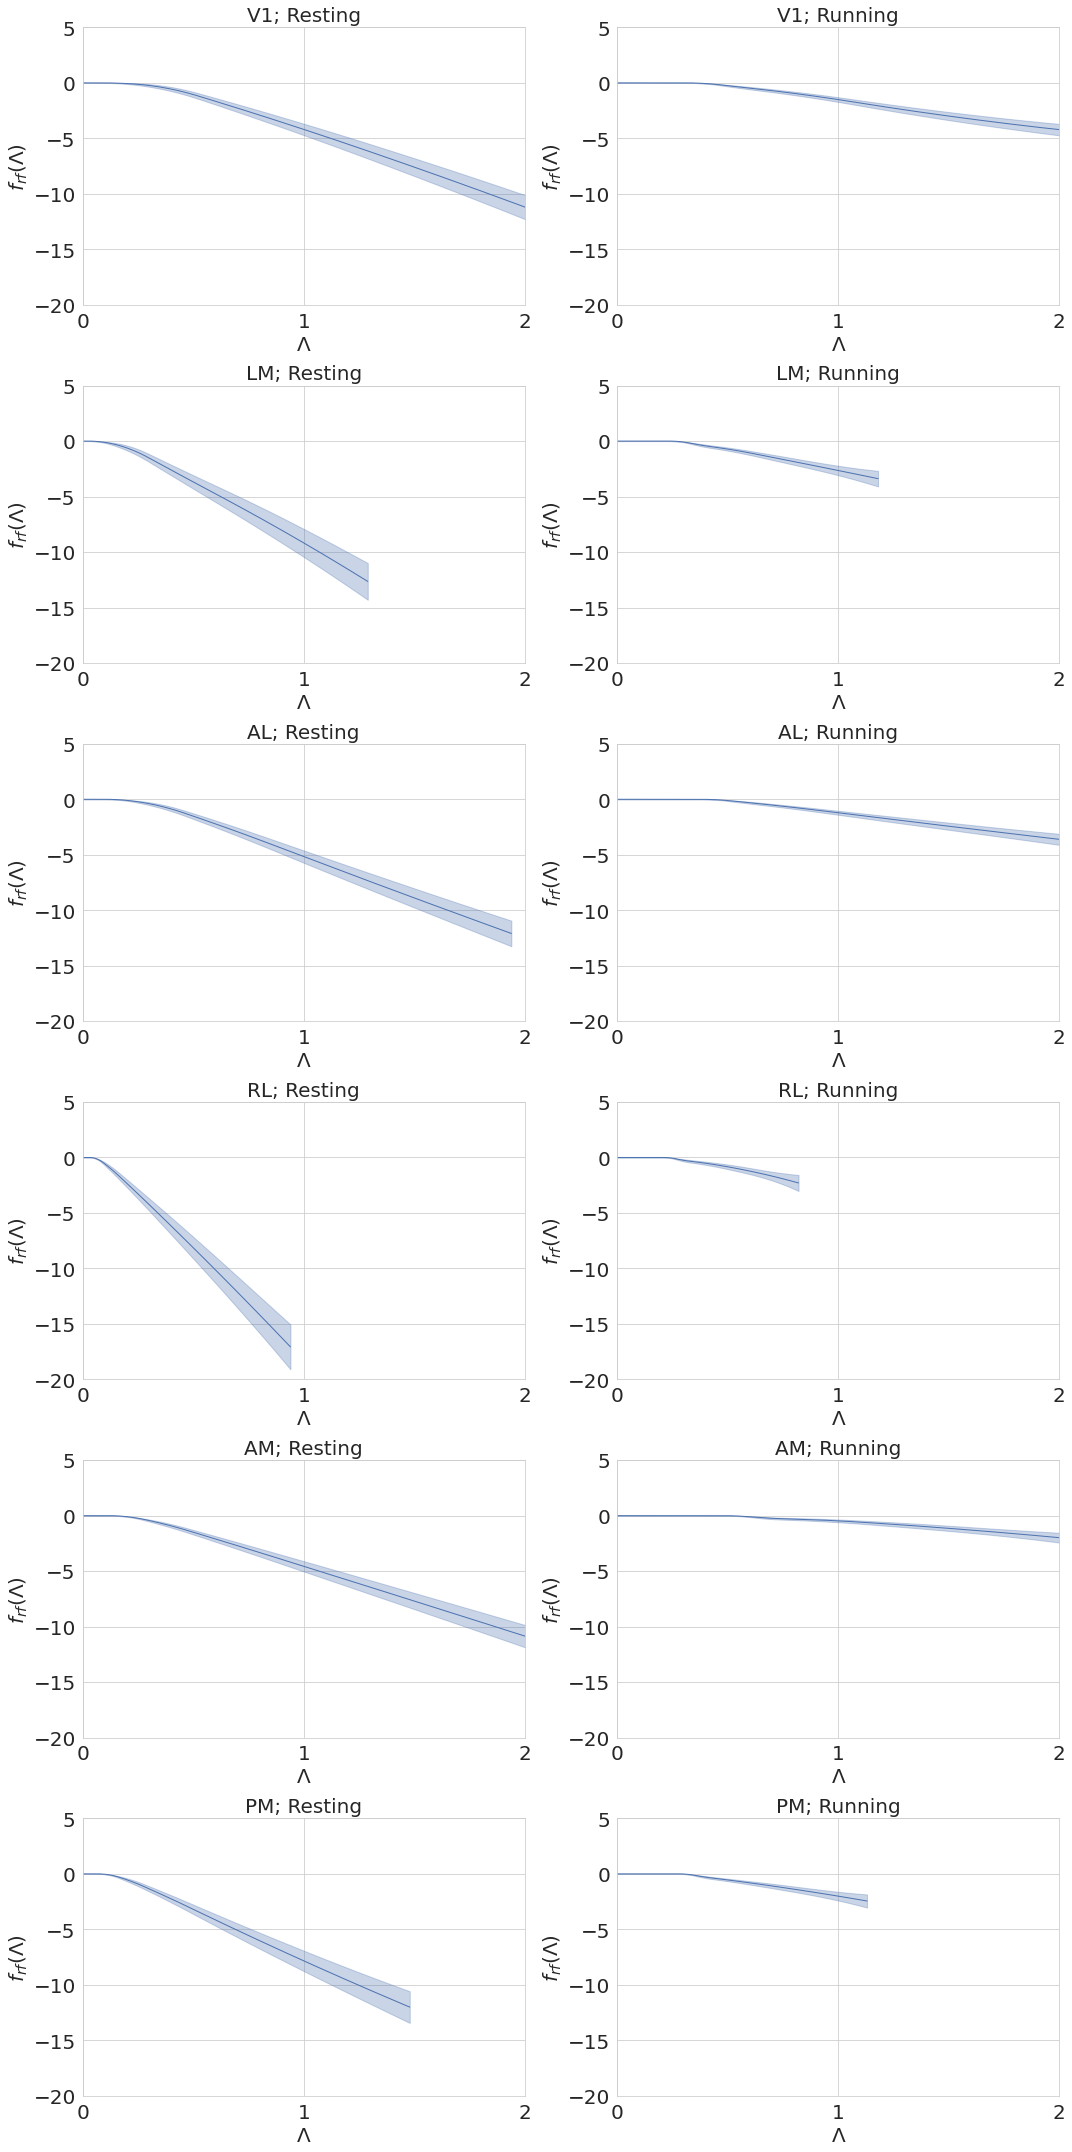

In [10]:
sns.set_style('whitegrid')
fontsize = 20
plt.subplots(figsize=(15,30))
transfer_ij = {4:0, 5:1, 0:2, 1:3, 2:4, 3:5}

model_list = stationary_model_list + running_model_list
for ii in range(6):
    i = transfer_ij[ii]
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-6)
        model = model_list[i]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Resting", fontdict = {'fontsize' : 20})
    for j in range(7,8):
        plt.subplot(6,2, 2*ii+j-5)
        model = model_list[i+6]
        utils.plot_ci(model.get_filter(ci=True)[j], center=True)
        plt.xticks(fontsize=fontsize)
        plt.yticks(fontsize=fontsize)
        plt.xlabel('$\Lambda$', fontsize=fontsize)
        plt.ylabel('$f_{rf}(\Lambda)$', fontsize=fontsize)
        plt.ylim([-20, 5])
        plt.xlim([0, 200])
        plt.xticks([0, 100, 200], [0, 1, 2])
        plt.title(utils.PROBE_CORRESPONDING[probe_list[i]]+"; Running", fontdict = {'fontsize' : 20})
plt.tight_layout()
sns.set_style('white')
